# Lesson 4: Gridded Data with Xarray

In this lesson, we are going to start looking at gridded data. This is data that can be stored in a multidimenaional array: think latitude, longitude, and time, although it doesn't have to be these three dimensions (or even three dimensions!). 

In these lessons, when working with general multi-dimensional (gridded) data we'll be using `xarray`, which is a great library with seemingly endless possibilities for processing and analyzing gridded data. The learning curve can be a little steep but stick with it and I guarantee you will learn to love `xarray`.


### Learning outcomes

After this lesson, you should be able to:

1) 
2) 
3)
4) 
5) 


:::{danger}
## Entry ticket!

This is your ticket into the lesson. Before we start, discuss with your neighbor for 1 minute the concept you found the most challenging from the last lesson.
:::

## Raster and Gridded Data

We often refer to higher level (i.e., pre-processed) satellite data as "raster data". Probably, you've come across raster data that represents some enviromental variable in a 2-dimensional (x, y) plane. But raster data is not limited to two dimensions! For example, multi-spectral satellite data has many bands of data on the same x and y plane. Now, we need to think in three dimensions (x, y, spectral band).

The difference between "raster" and "gridded" data is a little blurred, but the main distinction is that raster data is usually considered to be equidistant grids. This means that you don't have to store information about every single latitude and longitude, but it excludes data in certain projections. Here, we are going to use the term gridded data to broadly emcompass, "data that is representing an x and y plane in space". 

When working with general multi-dimensional (gridded) data we'll be using `xarray`:

![Summary Slide](./images/summary_xarray.jpg)

## Working up to Data Cubes

xarray is a library that allows us to manipulate **multidimensional data**. If you've taken linear algebra you might already be familiar with what that means. Multidimensional data is data that is organized using dimensions. Data can be 1-, 2-, or 3-dimensional, and can even be 4-, or 5-dimensional, and higher. Multidimensional data can be difficult to visualize if you haven't worked with it before, so before diving into code let's start by understanding multidimensional data visually first.

Let's start visualizaing a dataset where each number is represented by a little box like this:

![Data Element](./images/data_element.jpg)
<!-- <img src="images/data_element.jpg" width="330" /> -->
<!-- <img src="./images/data_element.jpg" width="200"/> -->

From now on every time you see a little box like this is represents a single data value (ex. an value for wind speed, water temperature, soil moisture, $CO_2$ concentration, etc.)

A one-dimensional dataset would be represented like this:

![1d_array](./images/1d_array.jpg)

Notice how the numbers aren't randomly placed, they are organized by a single dimension. In addition to dimensions we also often talk about the shape of a data array. The **shape** tells us how many values there are along each dimension of the dataset. The array above has a shape of `(9)`, because there are 9 values.

An example of a 1-dimensional dataset might be time series data from an ocean buoy showing water temperatures at each hour over the course of one day. (For the sake of space there are fewer boxes in the array than there are on the plot, but know that each dot on the plot would correspond to one box in a data array).

![1d_array_and_plot](./images/1d_array_and_plot.jpg)

This data is one dimensional because it is organized using one coordinate axis, which in this case is _time_.

If we were to use Python to represent this data we would need to specify one index to get a single value out of the dataset. 

In [4]:
# 1D Python data
water_temp = [15, 64, 23, 42, 34]

print("Third temperature value:", water_temp[2])

Third temperature value: 23


Two dimensional data has two dimensions, meaning data is organized using two sets of coordinates.

![2D Array](./images/2d_array.jpg)

The array above has a shape of `(9, 6)` because there are 9 values along the first dimensions and 6 values along the second dimension.

An example of 2D data might be sea surface temperatures over a region of the Pacific Ocean.

![2D Array with Example Data](./images/2d_array_and_plot.jpg)

In this example the two dimesions are _latitude_ and _longitude_.

If we were to use Python to represent this data we would need to use two indices to get one value out of the dataset.m

In [5]:
# 2D Python data
sst = [[15, 64, 23, 400], [304, 305, 300, 410]]

print("One temperature value:", sst[1][2])

One temperature value: 300


We can continue to make our data into more complex structures by adding additional dimensions. Here is an example of 3-dimensional data.

![3D Array](./images/3d_array.jpg)

In [6]:
co2 = [[[15, 64, 23, 400], [304, 305, 300, 410]], [[15, 64, 23, 400], [304, 305, 300, 410]]]

print("One CO2 value:", co2[0][1][3])

One CO2 value: 410


Now you may think that is the end of it, since we exist in three dimensions, but in math (and computer science) the concept of a "dimension" can continue into 4th, 5th, 6th dimensions and beyond. It doesn't make complete sense to visualize these things in space, but from a math and coding perspective we can continue to organize data into structures that can be described using 4, 5, and 6 dimensions.

The Python access would look like:

In [7]:
fourD = [[[[14, 15, 15], [34, 34, 34]], [[14, 15, 15], [34, 34, 34]]], [[[14, 15, 15], [34, 34, 34]], [[14, 15, 15], [34, 34, 34]]]]

print("One CO2 value:", fourD[1][0][1][2])

One CO2 value: 34


Does that long line of a list of a list of a list of a list look pretty ugly and hard to navigate to you? Good. Then you'll appreciate the benefit of xarray.

## xarray data structure: DataArray

`xarray` is a great (the?) library for working with gridded datasets. It has many built in analysis methods, nice visualization defaults, and it was built by the scientific community. `xarray` is built on top of another library called `numpy`. `xarray` takes the `numpy` arrays and makes them easier to work with by adding labels to the axes. This is a small change but it has a huge effect on the ease of working with data.

`xarray` allows us to work with labelled, multi-dimensional data. What does that mean? There are two parts:
1. **multi-dimensional:** the data is organized into a grid and can have any number of dimensions. For example, data might be organized by latitude, longitude, and altitude (3 dimensions). This is often visually represented as a cube of data.
2. **labelled:** the cube of data isn't just any old cube - each dimension has associated values. For example, we know the values of latitude, longitude, and altitude that the data is describing.

## Anatomy of a DataArray

The first core `xarray` data structure is a `DataArray`. Let's make a `DataArray` with some fake data for air temperature. We will need:
* values for temperature
* we need to know that our data is arranged by `latitude` and `longitude` 
* exactly which latitudes and longitudes our data are showing

In [8]:
import xarray as xr

# Data values
air_temps = [
    [80, 80, 81, 83, 82, 80], [81, 80, 81, 83, 83, 82], [81, 81, 83, 84, 84, 83], 
    [79, 80, 83, 85, 85, 85], [78, 77, 80, 85, 86, 87]
]
# Coordinate values
lats = [36, 37, 38, 39, 40]
lons = [-80, -79, -78, -77, -76, -75]
# Assemble the DataArray
temps = xr.DataArray(data=air_temps, dims=['latitude', 'longitude'], coords=[lats, lons],)

Don't worry too much about every line of the big code block above. You'll rarely ever need to create your own `DataArray`, as the most common thing is to open data from a file. More importantly, let's see what all that code created:

In [9]:
temps

<xarray.DataArray (latitude: 5, longitude: 6)> Size: 240B
array([[80, 80, 81, 83, 82, 80],
       [81, 80, 81, 83, 83, 82],
       [81, 81, 83, 84, 84, 83],
       [79, 80, 83, 85, 85, 85],
       [78, 77, 80, 85, 86, 87]])
Coordinates:
  * latitude   (latitude) int64 40B 36 37 38 39 40
  * longitude  (longitude) int64 48B -80 -79 -78 -77 -76 -75

What has xarray given us? An `xarray` `DataArray`. We get a nice output, and notice that it is clickable. We can see in the output that a `DataArray` has three major components:
1. `data`: values for temperature
2. `dims`: (_short for dimensions_) indicates that our data is arranged by `latitude` and `longitude`
3. `coords`: (_short for coordinates_) the values for latitude and longitude

The figure below shows where to find these three components in the xarray output. We see that this data is organized by latitude and longitude. The data covers 5 latitudes and 6 longitudes. The exact location of our data is shown in the coordinates, and the observed temperature values are listed in the main data array.

![xarray dataarray html output labelled](./images/labelled_html.png)

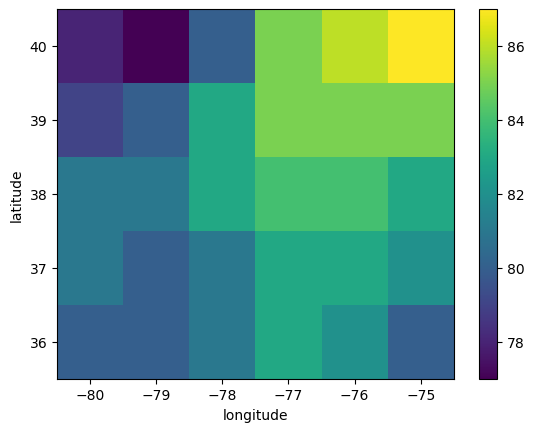

In [10]:
# Easy quick plotting with xarray
temps.plot()

We've created a plot of our temperature data! Each box of data is called a **pixel** and each pixel is colored to show the corresponding temperature value. We can see that the highest tempeatures are in the northeast corner of this plot while the lowest values are in the northwest corner.

And notice 🚨! We don't just have a random set of 30 temperature values. We have temperature values that represent a certain geographic location. Where is this data located? Where in the world is about $36-40^\circ$N and $75-80^\circ$W?

Right about here.

So, if we were to summarize the fake data we just made, we could say that we made data showing: 

> air temperature values over Virginia and Maryland

![study area map](./images/sample_geography.png)

## Summarizing datacube visualization

In the past few minutes we have now seen three different ways to visualize multidimensional data. We have:
1. The output from an xarray DataArray
2. A plot of two dimensional data
3. The graphical representation from earlier in this lesson

One of these three ways of visualizing may click better for you than others, and that's great. Going forward we will use a mixture of these representations, but remember that in the end they all represent the same thing: environmental data.

![2D Data Representations: xarray HTML, plot, schematic](./images/2d_data_representations.jpg)

In [11]:
# Data array attributes
print('DIMS', temps.dims)
print('COORDS', temps.coords)
print('DATA', temps.data)

DIMS ('latitude', 'longitude')
COORDS Coordinates:
  * latitude   (latitude) int64 40B 36 37 38 39 40
  * longitude  (longitude) int64 48B -80 -79 -78 -77 -76 -75
DATA [[80 80 81 83 82 80]
 [81 80 81 83 83 82]
 [81 81 83 84 84 83]
 [79 80 83 85 85 85]
 [78 77 80 85 86 87]]


## 3D DataArrays

Let's add a third dimension to our DataArray: altitude. 

Conceptually:

![Conceptual Drawing 3D Data](./images/fake_data_3d.jpg)

In [12]:
# Define the data
temperature_3d_values = np.random.randint(0, high=75, size=(3, 4, 6))

# Define the coordinates
altitude = [0, 500, 1000]
lats = [33, 34, 35, 36]
lons = [-122, -121, -120, -119, -118, -117]

# Assemble the DataArray
temperature_3d = xr.DataArray(temperature_3d_values, 
                      dims=['altitude', 'latitude', 'longitude'], 
                      coords=[altitude, lats, lons]
                     )
temperature_3d

<xarray.DataArray (altitude: 3, latitude: 4, longitude: 6)> Size: 576B
array([[[62, 49, 74, 39, 27, 59],
        [67, 10, 41, 20, 32, 53],
        [62, 72, 51, 18, 45, 17],
        [39, 42, 29, 68, 31, 50]],

       [[48, 20, 12, 60,  0, 51],
        [ 0, 10, 38, 29, 65, 64],
        [46, 37, 30, 61, 44,  1],
        [52, 57, 16, 42, 56,  2]],

       [[39, 37, 33, 42, 58, 28],
        [74, 67, 56, 42, 11, 32],
        [30, 54, 64,  6, 37, 43],
        [35, 49, 18, 33, 43, 14]]])
Coordinates:
  * altitude   (altitude) int64 24B 0 500 1000
  * latitude   (latitude) int64 32B 33 34 35 36
  * longitude  (longitude) int64 48B -122 -121 -120 -119 -118 -117

# Exercise: anatomty of a data array

The following `DataArray` contains values for wind speeds. 
1. What are the dimensions?
2. What are the coordinates?
3. What is the highest and lowest wind speed in the array?

![example output](./images/example_2d_repr.png)

## Indexing and Selecting Values

One of the great things about having labelled data is that we can use the labels to extract a smaller amount of data from a larger dataset. This process of extracting some data from a larger amount of data is called subsetting. **Subsetting** is the process of taking a large dataset and picking out just the bit of data that you need for your analysis. We do this in `xarray` using the `.sel()` selection syntax.

Now often you want to find not just a single value, but data over a larger area. For example, maybe the data file that you downloaded has data for the whole world but you only want data over the state of California. To achieve that we use a `slice()`.

Selecting by label is the most common way to use xarray, but sometimes you still want to use an index. When we talked about selecting data in lists we talked about a data **index**. Indexes let us say "_I want the first, second, and third elements_". `xarray` also lets you select data by index, but the syntax is different. Instead of square brackets we use the `.isel()` method and we give the names of our dimensions as arguments. 

In [14]:
# Get the value of the array where latitude is EQUAL TO 37 and longitude is EQUAL TO -19
temps.sel(latitude=37, longitude=-79)
# temps.sel(latitude=37, longitude=-79).data

<xarray.DataArray ()> Size: 8B
array(80)
Coordinates:
    latitude   int64 8B 37
    longitude  int64 8B -79

In [15]:
# Select all the data between (and including) 37 and 39 degrees north
temps.sel(latitude=slice(37, 39))

<xarray.DataArray (latitude: 3, longitude: 6)> Size: 144B
array([[81, 80, 81, 83, 83, 82],
       [81, 81, 83, 84, 84, 83],
       [79, 80, 83, 85, 85, 85]])
Coordinates:
  * latitude   (latitude) int64 24B 37 38 39
  * longitude  (longitude) int64 48B -80 -79 -78 -77 -76 -75

Notice, how does the shape of this dataset compare to the full dataset? Before we had an array of shape 5 x 6, with 5 latitudes and 6 longitudes. It was a 2-dimensional array. Now we still have a 2-dimensional array, but it is a smaller array. We have an array of shape 3 x 6, with 3 latitudes and 6 longitudes. 
![Graphic of select with slice](./images/select_example1.jpg)

In [16]:
# Using isel
temps.isel(longitude=3, latitude=0)
# temps.isel(latitude=0, longitude=3).data

# temps.isel(longitude=3)

<xarray.DataArray ()> Size: 8B
array(83)
Coordinates:
    latitude   int64 8B 36
    longitude  int64 8B -77

![Graphic of select from the exampe](./images/select_example2.jpg)

In [17]:
# We can also select DataArray values using numpy-like selection
# But often more intuitive to use sel and isel
temps[0, 3]  # returns a DataArray
# temps[0, 3].data # returns a numpy array 

# temps[:, 0:2]

<xarray.DataArray ()> Size: 8B
array(83)
Coordinates:
    latitude   int64 8B 36
    longitude  int64 8B -77

## Exercise: indexing and slicing

What is the shape of the output DataArray in each of the following selections? Use (latitude, longitude) order

1. `temps.sel(latitude=38, longitude=-75)`

2. `temps.sel(latitude=0)`

3. `temps.sel(longitude=slice(-79, -78))`

What would be the output sst values of the following lines of code?

1. `sst.isel(latitude=2, longitude=1)`
2. `sst.sel(latitude=38, longitude=-21)`
3. `sst.isel(latitude=2).sel(longitude=-21)`

3. Are these two functionally the same (i.e., do they give the same output)? `sst.isel(latitude=2).sel(longitude=-21)` `sst[0,4]`


## xarray data structure: Dataset

The other core data structure in `xarray` is a `Dataset`, which is a group of `DataArrays`.

![xarray_dataarray](./images/xarray_datarray.png)

To look at a `Dataset` let's go back to our example of air temperature in Virginia and Maryland. Let's say that in addition to air temperature temperature we also have data for humidity.

In [18]:
import numpy as np

# Create DataArray for chlorophyll-a
windspeed_values = np.random.uniform(4, high=13, size=(5, 6))
# Assemble the Dataset
air_dataset = xr.Dataset(
    data_vars={"temperature": temps, "wind_speed": (("latitude", "longitude"), windspeed_values)}
)

air_dataset

<xarray.Dataset> Size: 568B
Dimensions:      (latitude: 5, longitude: 6)
Coordinates:
  * latitude     (latitude) int64 40B 36 37 38 39 40
  * longitude    (longitude) int64 48B -80 -79 -78 -77 -76 -75
Data variables:
    temperature  (latitude, longitude) int64 240B 80 80 81 83 82 ... 80 85 86 87
    wind_speed   (latitude, longitude) float64 240B 11.38 4.472 ... 7.955 4.536

In the output we see that we have a new section: Data Variables where both temperature and wind speed are listed! The coordinates and dimensions are also maintained.

![xarray dataset html output labelled](./images/labelled_html_dataset.png)

In [4]:
# Access a DataArray containing the temperature data
air_dataset['temperature']

NameError: name 'air_dataset' is not defined

## Loading real data with xarray

The small dataset we made manually in the first part of this notebook is quite useful for learning. Usually, though, you won't be making your own data, you'll be opening other datasets. Let's try an example of that using a local file. Here we open up the dataset [NASA MUR](https://podaac.jpl.nasa.gov/dataset/MUR25-JPL-L4-GLOB-v04.2). This is a sea surface temperature dataset. We are opening up a MUR file stored locally, but you could re-download this file yourself from earthdata search.

:::{hint}
## File formats: NetCDF, HDF5, GRIB, Zarr

We've just seen our first real world gridded dataset. Did you notice the file extension? Files such as `.nc`, `.h5`, `.grib`, and `.zarr` are all common formats for storing raster or multidimensional data.

These formats are widely used in Earth science because they can efficiently store data that vary across space, time, and sometimes additional dimensions (e.g., depth, wavelength, ensemble member).

| Format | Typical Extension | Common Uses |
|:----------|:----------|:----------|
| NetCDF | `.nc` | Climate, weather, oceanography, remote sensing |
| HDF5 | `.h5`, `.hdf5` | Satellite products, scientific data archives |
| GRIB | `.grib`, `.grb` | Numerical weather prediction data |
| Zarr | `.zarr` | Cloud-native and large multidimensional datasets |

### NetCDF and HDF5

NetCDF (Network Common Data Form) and HDF5 (Hierarchical Data Format) are among the most common scientific data formats. Both can store multiple variables, dimensions, metadata, and coordinate systems within a single file. For example, a NetCDF file might contain daily precipitation with dimensions `(time, latitude, longitude)` along with metadata describing units, projection information, and variable names.:

### GRIB

GRIB (GRIdded Binary) is commonly used for weather forecast and reanalysis products. Many operational weather forecast centers distribute forecast datasets in GRIB format. GRIB files are highly optimized for storing large weather datasets but can be more difficult to work with than NetCDF.

### Zarr

Zarr is a newer format designed for cloud storage and parallel computing. Instead of storing everything in a single file, a Zarr dataset is typically stored as a directory containing many small chunks of data. This structure makes it possible to efficiently access only the portions of a dataset that are needed, which is particularly useful for very large datasets.

#### Reading gridded data with xarray

One of the advantages of `xarray` is that it provides a consistent interface for many different file formats.

```python
import xarray as xr

# NetCDF
ds = xr.open_dataset("precipitation.nc")

# HDF5 (many HDF products can also be opened this way)
ds = xr.open_dataset("satellite_data.h5")

# GRIB (requires cfgrib package)
ds = xr.open_dataset("forecast.grib", engine="cfgrib")

# Zarr
ds = xr.open_zarr("dataset.zarr")
```

#### Writing gridded data with xarray

Like pandas provides `to_csv()`, xarray includes methods for saving datasets to common scientific formats:

```python
# Save to NetCDF
ds.to_netcdf("output.nc")

# Save to Zarr
ds.to_zarr("output.zarr")
```
:::

In [20]:
sst = xr.open_dataset('./data/20250503090000-JPL-L4_GHRSST-SSTfnd-MUR25-GLOB-v02.0-fv04.2.nc')

sst

<xarray.Dataset> Size: 37MB
Dimensions:           (time: 1, lat: 720, lon: 1440)
Coordinates:
  * time              (time) datetime64[ns] 8B 2025-05-03T09:00:00
  * lat               (lat) float32 3kB -89.88 -89.62 -89.38 ... 89.62 89.88
  * lon               (lon) float32 6kB -179.9 -179.6 -179.4 ... 179.6 179.9
Data variables:
    analysed_sst      (time, lat, lon) float64 8MB ...
    analysis_error    (time, lat, lon) float64 8MB ...
    mask              (time, lat, lon) float32 4MB ...
    sea_ice_fraction  (time, lat, lon) float64 8MB ...
    sst_anomaly       (time, lat, lon) float64 8MB ...
Attributes: (12/54)
    Conventions:                CF-1.7, ACDD-1.3
    title:                      Daily 0.25-degree MUR SST, Interim near-real-...
    summary:                    A low-resolution version of the MUR SST analy...
    keywords:                   Oceans > Ocean Temperature > Sea Surface Temp...
    keywords_vocabulary:        NASA Global Change Master Directory (GCMD) Sc...
    standard_name_vocabulary:   NetCDF Climate and Forecast (CF) Metadata Con...
    ...                         ...
    publisher_name:             GHRSST Project Office
    publisher_url:              https://www.ghrsst.org
    publisher_email:            gpc@ghrsst.org
    file_quality_level:         3
    metadata_link:              http://podaac.jpl.nasa.gov/ws/metadata/datase...
    acknowledgment:             Please acknowledge the use of these data with...

:::{tip} 
## Reminder: data opening checklist

Recall our checklist for opening tabular data with pandas? Gridded data is no different. Remember to think through each of these when you open a new dataset.

1. What variables or measurements are available in this dataset?
2. How is the dataset organized? What is the shape or size?
3. What spatial and/or temporal range does this dataset cover?
4. Do there appear to be any nodata values in this dataset?
5. Do the variables appear to have reasonable values?
6. Make the simplest plot possible of 1-2 variables. Does it match your expectations?

:::

### Inspecting the data

One of the ways to inspect our data right after opening is to plot it. It's a great way to help us orient to the data and confirm that that it contains what we think it contains. Fortunately, xarray has great quick plotting functionality using `.plot()`.

In [26]:
sst.plot()

ValueError: Dataset.plot cannot be called directly. Use an explicit plot method, e.g. ds.plot.scatter(...)

:::{warning}
## Bug alert!

Oops! What happened?

`ValueError: Dataset.plot cannot be called directly. Use an explicit plot method, e.g. ds.plot.scatter(...)`

Here we see that xarray doesn’t like that we have given the .plot() method a Dataset. What if we gave it a DataArray instead? Let’s extract the analysed_sst variable before we attempt to plot.

:::

In [21]:
sst['analysed_sst']

<xarray.DataArray 'analysed_sst' (time: 1, lat: 720, lon: 1440)> Size: 8MB
[1036800 values with dtype=float64]
Coordinates:
  * time     (time) datetime64[ns] 8B 2025-05-03T09:00:00
  * lat      (lat) float32 3kB -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 6kB -179.9 -179.6 -179.4 -179.1 ... 179.4 179.6 179.9
Attributes:
    long_name:              analysed sea surface temperature
    standard_name:          sea_surface_foundation_temperature
    coverage_content_type:  physicalMeasurement
    units:                  kelvin
    valid_min:              -32767
    valid_max:              32767
    comment:                Interim near-real-time (nrt) version using Multi-...
    source:                 MODIS_T-JPL, MODIS_A-JPL, AMSR2-REMSS, AVHRRMTB_G...

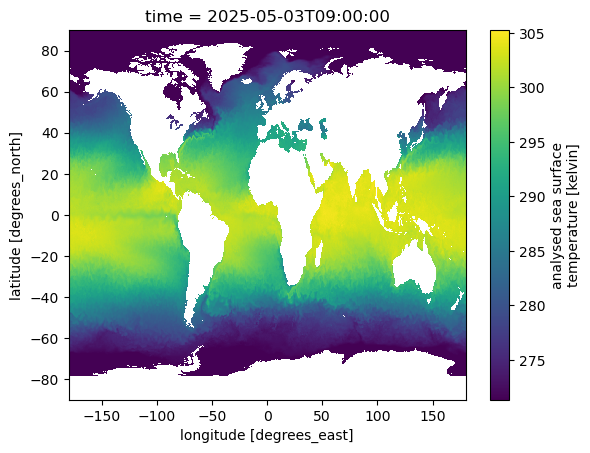

In [27]:
# Lets try to plot again, this time selecting the sst variable in the dataset
sst['analysed_sst'].plot()

In [28]:
# Note how this gives us a data array from our original dataset
sst['analysed_sst']

<xarray.DataArray 'analysed_sst' (time: 1, lat: 720, lon: 1440)> Size: 8MB
[1036800 values with dtype=float64]
Coordinates:
  * time     (time) datetime64[ns] 8B 2025-05-03T09:00:00
  * lat      (lat) float32 3kB -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 6kB -179.9 -179.6 -179.4 -179.1 ... 179.4 179.6 179.9
Attributes:
    long_name:              analysed sea surface temperature
    standard_name:          sea_surface_foundation_temperature
    coverage_content_type:  physicalMeasurement
    units:                  kelvin
    valid_min:              -32767
    valid_max:              32767
    comment:                Interim near-real-time (nrt) version using Multi-...
    source:                 MODIS_T-JPL, MODIS_A-JPL, AMSR2-REMSS, AVHRRMTB_G...

## Metadata

A new thing you will notice about this real dataset is that it has Attributes. Attributes are information about the data that isn't actually the data itself. These are also called **metadata**. Metadata is data about your data, but it isn't the actual data. Datasets and DataArrays can both have attributes.

Additionally, the dataset is large enough that not all the values can be shown in the output. When this happens xarray leaves some values out and denotes that with `...`. You can see an example of this in the `lat` coordiante, where the first and last two latitudes are shown with `...` in the middle to show you that some data was left out.

:::{admonition} Vocabulary
:class: tip
**Metadata:** information that describes your data, but isn’t the actual data values
:::

:::{admonition} 📝 Check your understanding
:class: tip

Describe the data we just opened:
- What is the data structure?
- How many dimensions does it have and what is the shape?
- How many variables are there? What are they?
- What geographic area is covered by this dataset? On what date(s) was data captured?
- What are the units of the `'analysed_sst'` data? 
- What is the source of the `sea_ice_fraction'` data?
:::

In [24]:
# Bringing back sel and slice
sst['analysed_sst'].sel(lat=slice(5, 65), lon=slice(-85, -36))

<xarray.DataArray 'analysed_sst' (time: 1, lat: 240, lon: 196)> Size: 376kB
[47040 values with dtype=float64]
Coordinates:
  * time     (time) datetime64[ns] 8B 2025-05-03T09:00:00
  * lat      (lat) float32 960B 5.125 5.375 5.625 5.875 ... 64.38 64.62 64.88
  * lon      (lon) float32 784B -84.88 -84.62 -84.38 ... -36.62 -36.38 -36.12
Attributes:
    long_name:              analysed sea surface temperature
    standard_name:          sea_surface_foundation_temperature
    coverage_content_type:  physicalMeasurement
    units:                  kelvin
    valid_min:              -32767
    valid_max:              32767
    comment:                Interim near-real-time (nrt) version using Multi-...
    source:                 MODIS_T-JPL, MODIS_A-JPL, AMSR2-REMSS, AVHRRMTB_G...

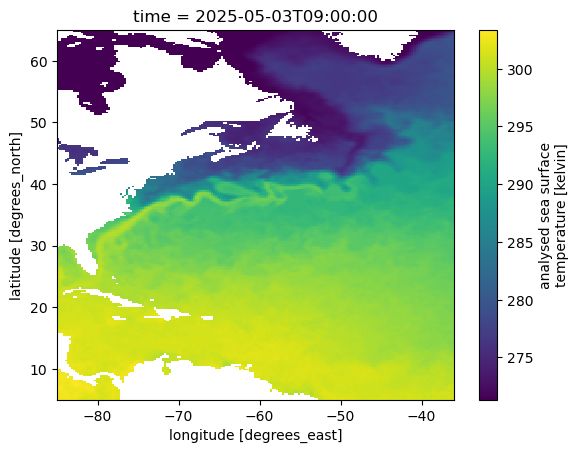

In [25]:
# Bringing back sel and slice
sst['analysed_sst'].sel(lat=slice(5, 65), lon=slice(-85, -36)).plot()

## Xarray functions/methods and aggregations

As we have already started to explore, xarray is a great tool for working with gridded and multidimensional data. xarray comes with a powerful suite of functions and methods that combine the labeled dimensions and metadata handling of NetCDF-style datasets with many of the familiar operations available in NumPy and pandas. 

#### Aggregations

Aggregations with xarray work in a similar way to the aggregations we have seen with pandas (the function names themselves are deliberately the same). Since we are working with multi-dimensional data, we now have to additionally specify the dimension(s) we are aggregating over. Most commonly, we will want to aggregate over either time (`dim='time'`) or space (`dim=['lat', 'lon']`):

| Function/Method | Description | Example |
|----------|-------------|---------|
| `mean()` | Calculate mean along one or more dimensions | `data.mean(dim='time')`, `data.mean(dim=['lat', 'lon'])` |
| `min()` | Calculate max along one or more dimensions | `data.min(dim='time')` |
| `max()` | Calculate max along one or more dimensions | `data.max(dim='time')` |
| `sum()` | Sum values along one or more dimensions | `data.sum(dim='time')` |
| `count()` | Count values along one or more dimensions | `data.count(dim='time')` |

### Other common functions/methods

Other common tasks on gridded data include filtering / masking certain values, resampling time series, changing spatial resolution, interpolating between coordinates, combining variables, and performing mathematical operations. Here are just some of the functions you might find most relevant:

| Function/Method | Description | Example |
|----------|-------------|---------|
| `where()` | Keep values meeting a condition, mask others | `data.where(ds.precip > 0)` |
| `resample()` | Aggregate or interpolate along time | `data.resample(time='M').mean()` |
| `coarsen()` | Aggregate to a lower spatial or temporal resolution | `data.coarsen(lat=2, lon=2).mean()` |
| `groupby()` | Group data by a coordinate or attribute | `data.groupby('time.month').mean()`, `data.groupby('time.season').mean()` |
| `rolling()` | Apply moving-window operations | `data.rolling(time=7).mean()` |
| `interp()` | Interpolate to new coordinates | `data.interp(lat=35.5, lon=-97.5)` |

In [ ]:
# Adjust these for SST example
band2.where(band2 > 0)

(band2 > 0.6) & (band2 < 0.8)

band2.max(axis=1)
band2.max(dim='x')

:::{admonition} 

## Exercise

Create a plot that shows where sst is above 10 degrees.

:::

## Groupby: the power of xarray for aggregating

While we have lots of individual gridpoints in our dataset, sometimes we don't care about each individual reading.  Instead we probably care about the aggregate of a specific group of readings. 

For example:
* Given the average temperature of every county in the US, what is the average temperature in each state?
* Given a list of the opening dates of every Chuck E Cheese stores, how many Chuck E Cheeses were opened each year? 🧀

In xarray we answer questions like that that with `groupby`.

In addition to the dataframe, there are three main parts to a groupby:
1. Which variable we want to group together
2. How we want to group
3. The variable we want to see in the end

### Breaking down the process

There is a lot that happens in a single step with `groupby` and it can be a lot to take in.  One way to mentally situate this process is to think about **split-apply-combine**.

**split-apply-combine** breaks down the `groupby` process into those three steps:
1. SPLIT the full data set into groups.  Split is related to the question _Which variable to group together?_
2. APPLY the aggregation function to the individual groups.  Apply is related to the question _How do we want to group?_
3. COMBINE the aggregated data into a new dataframe


<img src="https://static.packt-cdn.com/products/9781783985128/graphics/5128OS_09_01.jpg" width=550>

:::{admonition} 

## Exercise: thinking through groupby components

Identify each of three main groupby parts in the following scenario:

**Given the hourly temperatures for a location over the course of a month, what were the daily highs?**

1. _Which variable to group together?_
2. _How do we want to group?_
3. _What variable do we want to look at?_

:::

In [35]:
sst = xr.open_dataset('./data/oisst-avhrr-v02r01.20220304.nc')
sst = sst['sst'].squeeze(dim='zlev', drop=True)

<xarray.DataArray 'sst_anomaly' (time: 1, lat: 720, lon: 1440)> Size: 8MB
[1036800 values with dtype=float64]
Coordinates:
  * time     (time) datetime64[ns] 8B 2025-05-03T09:00:00
  * lat      (lat) float32 3kB -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 6kB -179.9 -179.6 -179.4 -179.1 ... 179.4 179.6 179.9
Attributes:
    long_name:              SST anomaly from a seasonal SST climatology based...
    coverage_content_type:  auxiliaryInformation
    units:                  kelvin
    valid_min:              -32767
    valid_max:              32767
    comment:                anomaly reference to the day-of-year average betw...

In [33]:
sst = sst['sst_anomaly']
# We only have 1 month, so this doesn't fly here  maybe on homework?
sst.groupby('time.month').mean()

<xarray.DataArray 'sst_anomaly' (month: 1, lat: 720, lon: 1440)> Size: 8MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.]]])
Coordinates:
  * month    (month) int64 8B 5
  * lat      (lat) float32 3kB -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 6kB -179.9 -179.6 -179.4 -179.1 ... 179.4 179.6 179.9
Attributes:
    long_name:              SST anomaly from a seasonal SST climatology based...
    coverage_content_type:  auxiliaryInformation
    units:                  kelvin
    valid_min:              -32767
    valid_max:              32767
    comment:                anomaly reference to the day-of-year average betw...

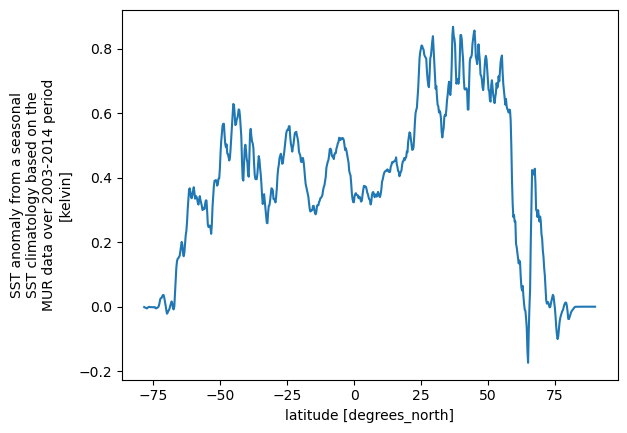

In [34]:
sst.groupby('lat').mean(...).plot()

:::{danger}
## Exit ticket!

This is your ticket outta here. Before you leave this lesson, please submit your responses to the following questions using this link: INSERT LINK

* Give an overall rating of how much of this lesson's content you feel you are now comfortable with? Indicate on a 0-10 scale, with 10 being you are comfortable with all of the content.
* How was the pace of this lesson for you? 1) Too slow; 2) About right; 3) Too fast.
* Briefly, what was the single concept you found most challenging in this lesson? 

:::

:::{hint}
## Further reading

* [Xarray tutorial](https://xarray-contrib.github.io/xarray-tutorial/)
* [UW Geohackweek Xarray tutorial](https://geohackweek.github.io/nDarrays/)
* SARP Programming Lessons [3.2 (band math)](https://nasa-sarp.github.io/sarp_lessons/sarp_lessons/1_python_progression/3-gridded_data/3-2_xarray_computation.html) and [3.3 (group by)](https://nasa-sarp.github.io/sarp_lessons/sarp_lessons/1_python_progression/3-gridded_data/3-3_xarray_groupby.html)